Варіант 6
Місто: Чернігів
λ = 0.22
Теоретичне середнє E[X] = 4.545 хв

ЗАВДАННЯ 1
--------------------------------------------------
n =     5 | середнє = 2.4982 | абсолютна різниця = 2.0472
n =    50 | середнє = 4.5487 | абсолютна різниця = 0.0033
n =   500 | середнє = 4.4527 | абсолютна різниця = 0.0928
n = 20000 | середнє = 4.5147 | абсолютна різниця = 0.0307

ЗАВДАННЯ 2
--------------------------------------------------
n = 10   | середнє x̄ = 4.5574
n = 300  | середнє x̄ = 4.5396


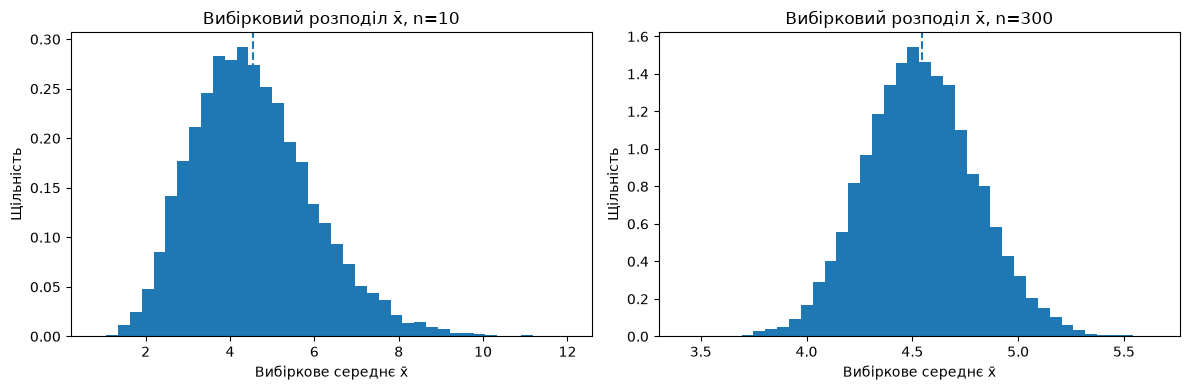


ЗАВДАННЯ 3
----------------------------------------------------------------------
    n |      Теоретична SE |       Виміряна std
----------------------------------------------------------------------
   10 |             1.4374 |             1.4364
   30 |             0.8299 |             0.8386
  100 |             0.4545 |             0.4610
  300 |             0.2624 |             0.2638

ЗАВДАННЯ 4
--------------------------------------------------
SE для n = 25:  0.9091
SE для n = 100: 0.4545
Відношення SE(25) / SE(100): 2.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# ПРАКТИКА 11
# Варіант 6

rng = np.random.default_rng(6)

lam = 0.22
true_mean = 1 / lam

print("Варіант 6")
print("Місто: Чернігів")
print(f"λ = {lam}")
print(f"Теоретичне середнє E[X] = {true_mean:.3f} хв")


# ============================================================
# ЗАВДАННЯ 1. Перевірка закону великих чисел
# ============================================================

print("\nЗАВДАННЯ 1")
print("-" * 50)

for n in [5, 50, 500, 20_000]:
    sample = rng.exponential(scale=1 / lam, size=n)
    sample_mean = sample.mean()
    difference = abs(sample_mean - true_mean)

    print(
        f"n = {n:5d} | "
        f"середнє = {sample_mean:.4f} | "
        f"абсолютна різниця = {difference:.4f}"
    )


# Письмова відповідь:
#
# Зі збільшенням розміру вибірки n вибіркове середнє x̄
# наближається до теоретичного середнього E[X] = 1/λ ≈ 4.545 хв.
# Абсолютна різниця між вибірковим і теоретичним середнім
# загалом зменшується. Для малої вибірки результат може помітно
# відрізнятися від теоретичного значення через випадковість.
# При n = 20 000 середнє вже має бути дуже близьким до 4.545 хв.
#
# Це демонструє закон великих чисел: зі зростанням кількості
# спостережень вибіркове середнє наближається до математичного
# сподівання випадкової величини.


# ============================================================
# ЗАВДАННЯ 2. Вибірковий розподіл середнього для двох n
# ============================================================

print("\nЗАВДАННЯ 2")
print("-" * 50)

n_repeats = 10_000

# 10 000 повторних вибірок по 10 спостережень
means_n10 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 10)
).mean(axis=1)

# 10 000 повторних вибірок по 300 спостережень
means_n300 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 300)
).mean(axis=1)

print(f"n = 10   | середнє x̄ = {means_n10.mean():.4f}")
print(f"n = 300  | середнє x̄ = {means_n300.mean():.4f}")


# Побудова двох гістограм
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(means_n10, bins=40, density=True)
axes[0].axvline(true_mean, linestyle="--")
axes[0].set_title("Вибірковий розподіл x̄, n=10")
axes[0].set_xlabel("Вибіркове середнє x̄")
axes[0].set_ylabel("Щільність")

axes[1].hist(means_n300, bins=40, density=True)
axes[1].axvline(true_mean, linestyle="--")
axes[1].set_title("Вибірковий розподіл x̄, n=300")
axes[1].set_xlabel("Вибіркове середнє x̄")
axes[1].set_ylabel("Щільність")

plt.tight_layout()
plt.show()


# Письмова відповідь:
#
# При n = 10 розподіл вибіркового середнього ще помітно скошений
# вправо, оскільки вихідний експоненційний розподіл також сильно
# скошений вправо.
#
# При n = 300 розподіл вибіркового середнього стає значно більш
# симетричним і набуває дзвоноподібної форми, близької до нормальної.
#
# Це демонструє центральну граничну теорему: навіть якщо вихідна
# випадкова величина має скошений експоненційний розподіл,
# розподіл вибіркового середнього при достатньо великому n
# наближається до нормального.


# ============================================================
# ЗАВДАННЯ 3. Стандартна похибка:
# теорія проти симуляції
# ============================================================

print("\nЗАВДАННЯ 3")
print("-" * 70)

print(
    f"{'n':>5} | "
    f"{'Теоретична SE':>18} | "
    f"{'Виміряна std':>18}"
)
print("-" * 70)

for n in [10, 30, 100, 300]:

    # Повторні вибірки
    sample_means = rng.exponential(
        scale=1 / lam,
        size=(n_repeats, n)
    ).mean(axis=1)

    # Теоретична стандартна похибка
    se_theoretical = (1 / lam) / np.sqrt(n)

    # Стандартне відхилення отриманих вибіркових середніх
    se_measured = sample_means.std()

    print(
        f"{n:5d} | "
        f"{se_theoretical:18.4f} | "
        f"{se_measured:18.4f}"
    )


# Письмова відповідь:
#
# Теоретична стандартна похибка обчислюється за формулою:
#
# SE = (1/λ) / √n
#
# Для нашого варіанта λ = 0.22, тому:
#
# SE = 4.545 / √n
#
# Виміряне стандартне відхилення масиву sample_means має бути
# близьким до теоретичної SE. Невелика різниця виникає через
# випадковість симуляції та обмежену кількість повторних вибірок.
#
# Зі збільшенням n стандартна похибка зменшується. Це означає,
# що середнє значення стає точнішою оцінкою теоретичного
# математичного сподівання.


# ============================================================
# ЗАВДАННЯ 4. Закон убуваючої віддачі
# ============================================================

print("\nЗАВДАННЯ 4")
print("-" * 50)

se_25 = (1 / lam) / np.sqrt(25)
se_100 = (1 / lam) / np.sqrt(100)

print(f"SE для n = 25:  {se_25:.4f}")
print(f"SE для n = 100: {se_100:.4f}")
print(f"Відношення SE(25) / SE(100): {se_25 / se_100:.1f}")


# Письмова відповідь:
#
# Для n = 25:
# SE = 4.545 / √25 = 0.9091
#
# Для n = 100:
# SE = 4.545 / √100 = 0.4545
#
# При збільшенні вибірки з 25 до 100, тобто у 4 рази,
# стандартна похибка зменшилася у 2 рази.
#
# Вона зменшується не у 4 рази, тому що у формулі SE = σ/√n
# розмір вибірки знаходиться під квадратним коренем.
# Якщо n збільшити у 4 рази, √n збільшиться у 2 рази,
# тому SE зменшиться у 2 рази.
#
# Практично це означає, що для зменшення стандартної похибки
# вдвічі потрібно збільшити кількість спостережень у 4 рази.
# Це і є прояв закону убуваючої віддачі: для подальшого
# підвищення точності потрібно збирати все більше даних.


# ============================================================
# КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

# 1. Чим відрізняється закон великих чисел від ЦГТ?
#
# Закон великих чисел відповідає на питання:
# "Куди прямує x̄?"
#
# Він гарантує, що при збільшенні розміру вибірки вибіркове
# середнє x̄ наближається до теоретичного математичного
# сподівання E[X].
#
# Центральна гранична теорема відповідає на питання:
# "Яка форма і розкид у x̄?"
#
# Вона показує, що при достатньо великому n розподіл
# вибіркового середнього наближається до нормального,
# а його стандартне відхилення визначається стандартною
# похибкою SE = σ/√n.
#
# Отже:
# Закон великих чисел -> куди прямує x̄.
# ЦГТ -> яка форма і який розкид має x̄.


# 2. Чому вихідний розподіл обрано сильно скошеним?
#
# У практиці використовується експоненційний розподіл,
# який сильно скошений вправо.
#
# Це зроблено для того, щоб було добре видно дію центральної
# граничної теореми. Якщо одразу використовувати нормально
# розподілені дані, то вибірковий розподіл середнього також
# буде нормальним, і перехід від скошеної форми до
# дзвоноподібної форми було б складно продемонструвати.
#
# На експоненційному розподілі добре видно, що навіть із
# початково скошених даних розподіл x̄ при збільшенні n
# стає приблизно нормальним.


# 3. Чому SE зменшується пропорційно √n, а не n?
#
# Стандартна похибка визначається формулою:
#
# SE = σ / √n
#
# Тому збільшення n у 4 рази призводить лише до зменшення
# SE у 2 рази, оскільки √4 = 2.
#
# Щоб зменшити стандартну похибку вдвічі, потрібно збільшити
# кількість спостережень у 4 рази.
#
# Наприклад:
# n = 25 -> SE ≈ 0.9091
# n = 100 -> SE ≈ 0.4545
#
# Отже, підвищення точності потребує непропорційно великого
# збільшення кількості даних.


# ============================================================
# ПІДСУМОК
# ============================================================

# У ході практичної роботи для варіанта 6 (Чернігів, λ = 0.22)
# було проведено симуляцію експоненційно розподіленого часу
# очікування.
#
# У Завданні 1 перевірено закон великих чисел: зі збільшенням
# n вибіркове середнє наближається до теоретичного E[X] ≈ 4.545 хв.
#
# У Завданні 2 продемонстровано центральну граничну теорему:
# при n = 10 розподіл x̄ ще має скошеність, а при n = 300
# стає близьким до нормального.
#
# У Завданні 3 теоретичну стандартну похибку SE = σ/√n
# порівняно зі стандартним відхиленням симульованих вибіркових
# середніх. Значення виявилися близькими.
#
# У Завданні 4 показано закон убуваючої віддачі:
# збільшення вибірки у 4 рази зменшує стандартну похибку
# лише у 2 рази.


ЗАВДАННЯ 5
--------------------------------------------------
n = 10
Кількість повторних вибірок = 50
Середнє отриманих x̄ = 4.1978
Стандартне відхилення x̄ = 1.1858


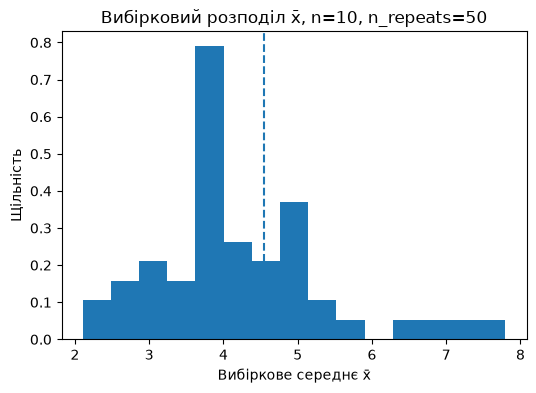

In [2]:
# ============================================================
# ЗАВДАННЯ 5. Вплив величини n_repeats на якість симуляції
# ============================================================

print("\nЗАВДАННЯ 5")
print("-" * 50)

# Для n = 10 використовуємо лише 50 повторних вибірок
n = 10
n_repeats_small = 50

means_n10_small = rng.exponential(
    scale=1 / lam,
    size=(n_repeats_small, n)
).mean(axis=1)

print(f"n = {n}")
print(f"Кількість повторних вибірок = {n_repeats_small}")
print(f"Середнє отриманих x̄ = {means_n10_small.mean():.4f}")
print(f"Стандартне відхилення x̄ = {means_n10_small.std():.4f}")


# Побудова гістограми для 50 повторних вибірок
plt.figure(figsize=(6, 4))
plt.hist(means_n10_small, bins=15, density=True)
plt.axvline(true_mean, linestyle="--")
plt.title("Вибірковий розподіл x̄, n=10, n_repeats=50")
plt.xlabel("Вибіркове середнє x̄")
plt.ylabel("Щільність")
plt.show()


# Письмова відповідь:
#
# При n = 10 та n_repeats = 50 гістограма виходить значно
# менш гладкою та менш стабільною, ніж гістограма із
# n_repeats = 10 000.
#
# Причина полягає в тому, що n_repeats визначає кількість
# отриманих значень вибіркового середнього x̄, з яких будується
# гістограма. При 50 повтореннях значень мало, тому гістограма
# може мати нерівну форму та сильніше залежати від випадковості.
#
# При n_repeats = 10 000 значень x̄ набагато більше, тому
# гістограма стає гладкішою і краще показує справжню форму
# вибіркового розподілу.
#
# Водночас n визначає розмір кожної окремої вибірки та впливає
# на форму самого розподілу x̄. Збільшення n робить розподіл
# середнього більш близьким до нормального та зменшує його
# стандартну похибку.
#
# Отже:
# n -> впливає на форму та розкид вибіркового середнього.
# n_repeats -> впливає на якість і гладкість гістограми,
#              тобто наскільки добре ми бачимо цей розподіл.